# Analysis of the Corpus callosum


## The Body

In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind



path = '/home/daniela/Documents/PROJECTS/Aging_DWI/DTI_MAPS_all/ROIstats'
CC_file= 'Regions_CC_DTIvalues.csv'
df_CC_body= pd.read_csv(f"{path}/{CC_file}")
df_CC_body.head()


,list_sub,group,age,sex,JND_P,JND_T,IHD,FA_body,AD_body,MD_body,RD_body,FA_genu,AD_genu,MD_genu,RD_genu,FA_splenium,AD_splenium,MD_splenium,RD_splenium
0,sub-01,Y,25,F,9.56,4.21,0.534027,0.583305,0.001200,0.000678,0.000417,0.534531,0.001265,0.000769,0.000521,0.671109,0.001202,0.000619,0.000327
1,sub-02,Y,27,M,6.69,11.62,0.570600,0.613541,0.001163,0.000638,0.000376,0.554182,0.001191,0.000711,0.000471,0.696520,0.001134,0.000571,0.000289
2,sub-03,Y,28,F,12.92,3.79,-0.140120,0.627874,0.001173,0.000631,0.000361,0.557587,0.001212,0.000710,0.000459,0.702712,0.001195,0.000596,0.000296
3,sub-05,Y,21,F,1.95,1.28,0.488581,0.596940,0.001187,0.000665,0.000403,0.536202,0.001224,0.000736,0.000492,0.680835,0.001187,0.000607,0.000317
4,sub-06,Y,25,F,2.54,2.22,0.578001,0.637035,0.001197,0.000636,0.000356,0.571072,0.001168,0.000674,0.000427,0.715834,0.001239,0.000606,0.000290


/tmp/ipykernel_165115/2135029641.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='group', y=DTImetric,data=df_CC_body, ax=ax, hue='group', marker='o', linewidth=0.9, color='gray', alpha=0.6)
/tmp/ipykernel_165115/2135029641.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='group', y=DTImetric,data=df_CC_body, ax=ax, hue='group', marker='o', linewidth=0.9, color='gray', alpha=0.6)
/tmp/ipykernel_165115/2135029641.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='group', y=DTImetric,data=df_CC_body, ax=ax, hue='group', marker='o', linewidth=0.9, color='gray', alpha=0.6)
/tmp/ipykernel_165115/2135029641.py:11: Fut

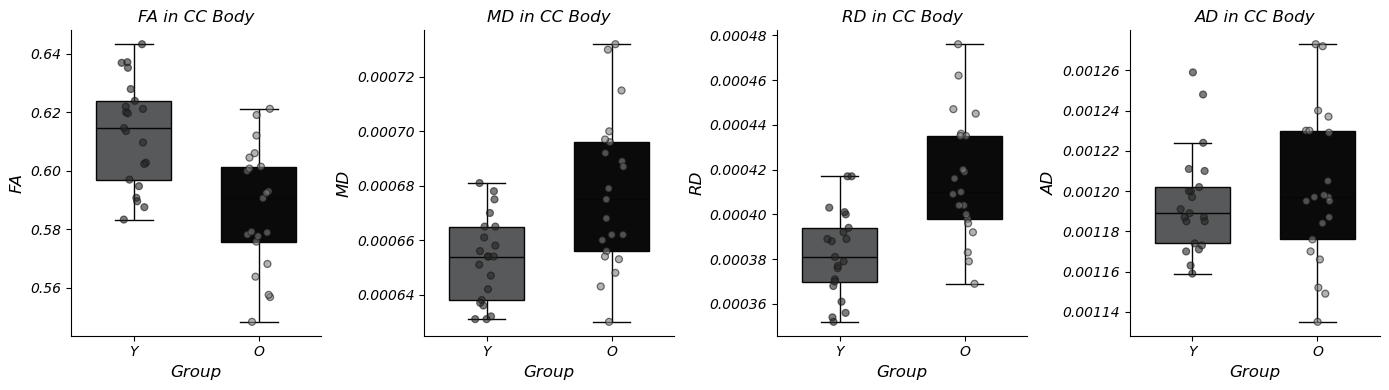

In [4]:
group_colors = {'Y': "#015ed7", 'O': "#ea231d"}
group_colors = {'Y': "#58595A89", 'O': "#0a0a0aae"}

metrics = ['FA', 'MD', 'RD', 'AD']
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    DTImetric = metric + '_body'
    sns.boxplot(x='group', y=DTImetric, data=df_CC_body, ax=ax, hue='group', palette=group_colors, showfliers=False, width=0.6, boxprops=dict(alpha=1), linewidth=1)
    sns.stripplot(x='group', y=DTImetric,data=df_CC_body, ax=ax, hue='group', marker='o', linewidth=0.9, color='gray', alpha=0.6)
    # size of the tittles
    ax.set_title(f"{metric} in CC Body", fontsize=12)
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
# quality of the image - dpi=300
plt.rcParams['figure.dpi'] = 300
# despine
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# statistical t test for metric in metrics:
for metric in metrics:
    DTImetric = metric + '_body'
    group_Y = df_CC_body[df_CC_body['group'] == 'Y'][DTImetric]
    group_Y = group_Y.dropna()
    group_O = df_CC_body[df_CC_body['group'] == 'O'][DTImetric] 
    group_O = group_O.dropna()
    t_stat, p_value = ttest_ind(group_Y, group_O)
    print(f"{metric}: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}")
    # print descriptive statistics
    print(f"{metric} - Group Y: mean = {group_Y.mean():.3f}, std = {group_Y.std():.3f}, n = {len(group_Y)}")
    print(f"{metric} - Group O: mean = {group_O.mean():.3f}, std = {group_O.std():.3f}, n = {len(group_O)}")

FA: t-statistic = 4.328, p-value = 0.000
FA - Group Y: mean = 0.613, std = 0.018, n = 21
FA - Group O: mean = 0.587, std = 0.021, n = 21
MD: t-statistic = -3.488, p-value = 0.001
MD - Group Y: mean = 0.001, std = 0.000, n = 21
MD - Group O: mean = 0.001, std = 0.000, n = 21
RD: t-statistic = -4.550, p-value = 0.000
RD - Group Y: mean = 0.000, std = 0.000, n = 21
RD - Group O: mean = 0.000, std = 0.000, n = 21
AD: t-statistic = -0.632, p-value = 0.531
AD - Group Y: mean = 0.001, std = 0.000, n = 21
AD - Group O: mean = 0.001, std = 0.000, n = 21


FA: t-statistic = 4.328, p-value = 0.000
MD: t-statistic = -3.492, p-value = 0.001
RD: t-statistic = -4.570, p-value = 0.000
AD: t-statistic = -0.631, p-value = 0.531

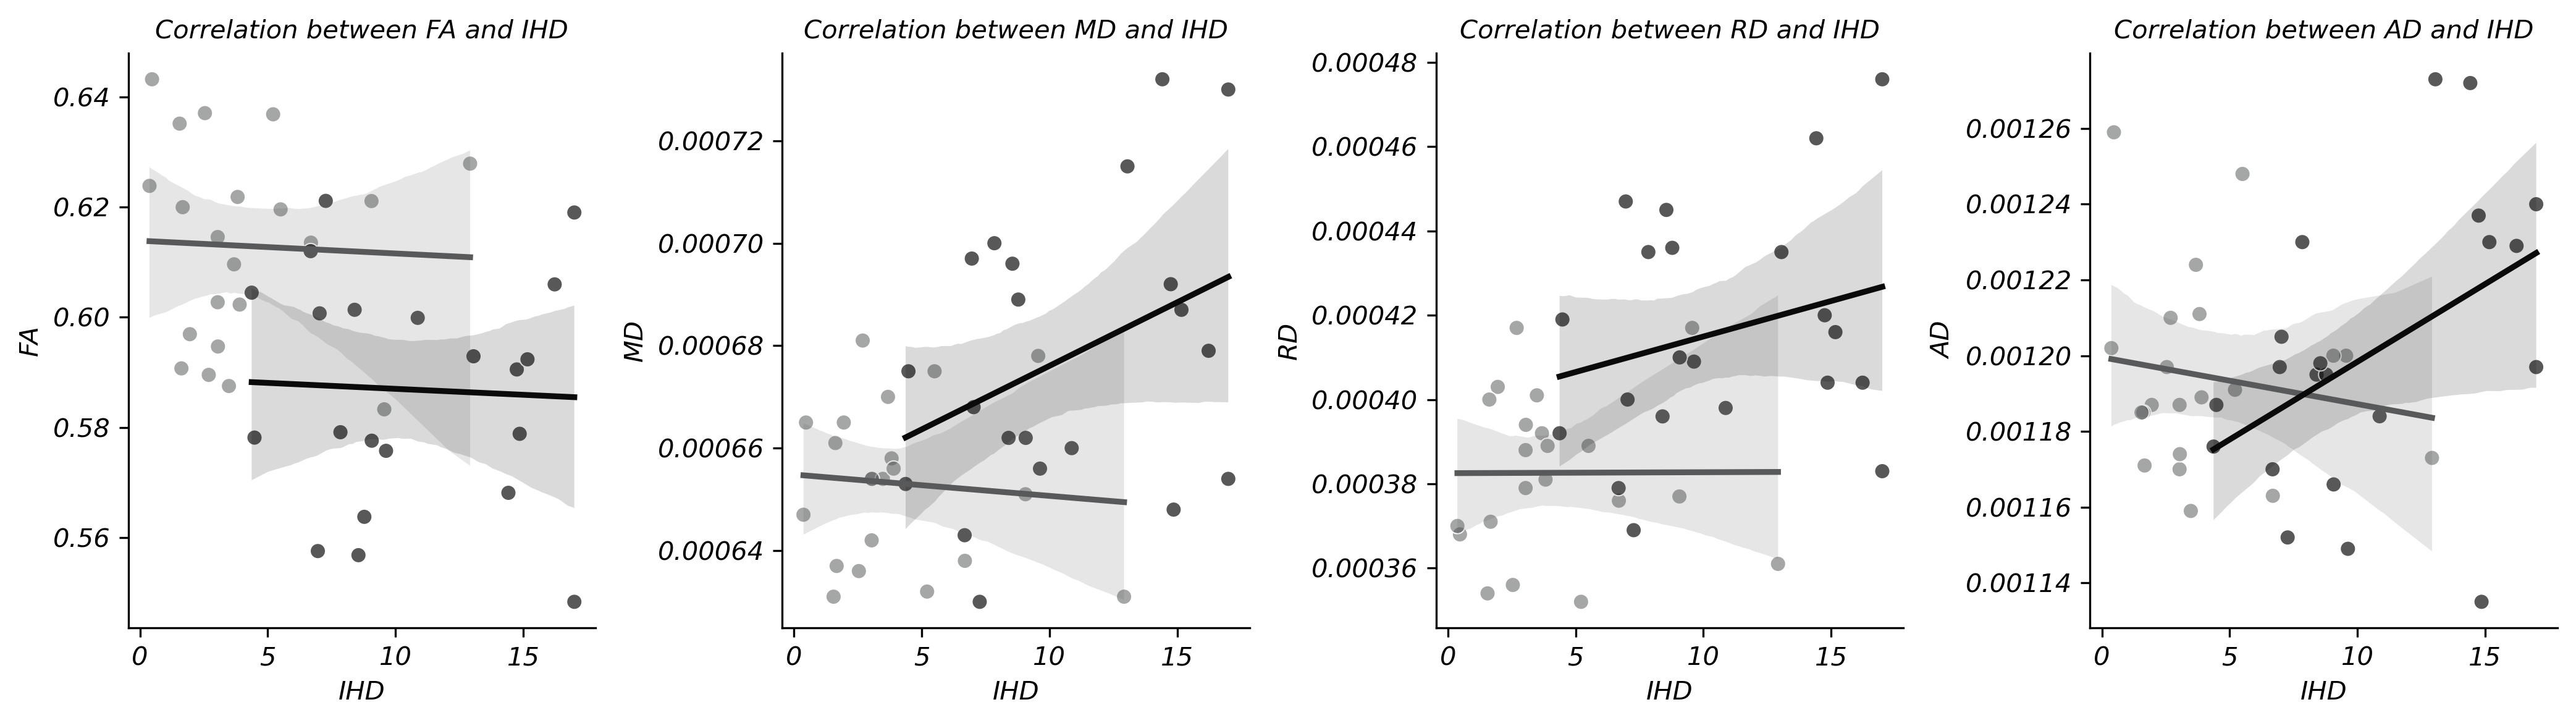

Metric: FA, Correlation: -0.40, p-value: 0.0079
Metric: MD, Correlation: 0.47, p-value: 0.0016
Metric: RD, Correlation: 0.49, p-value: 0.0009
Metric: AD, Correlation: 0.25, p-value: 0.1154
Group: Y, Metric: FA, Correlation: -0.04, p-value: 0.8612
Group: O, Metric: FA, Correlation: -0.04, p-value: 0.8537
Group: Y, Metric: MD, Correlation: -0.08, p-value: 0.7163
Group: O, Metric: MD, Correlation: 0.37, p-value: 0.1014
Group: Y, Metric: RD, Correlation: 0.00, p-value: 0.9873
Group: O, Metric: RD, Correlation: 0.25, p-value: 0.2698
Group: Y, Metric: AD, Correlation: -0.15, p-value: 0.5089
Group: O, Metric: AD, Correlation: 0.45, p-value: 0.0402


In [6]:
# correlation plots between the DTI measures in the Body_CC and the IHD, for each group
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
x_var = 'JND_P'
fig, axes = plt.subplots(1, 4, figsize=(14,4))
for ax, metric in zip(axes.flatten(), metrics):
    DTImetric = metric + '_body'
    sns.scatterplot(data=df_CC_body, x=x_var, y=DTImetric, hue='group', ax=ax, palette=group_colors)
    # add a regression line for each group
    sns.regplot(data=df_CC_body[df_CC_body['group'] == 'Y'], x=x_var, y=DTImetric, ax=ax, scatter=False, color=group_colors['Y'])
    sns.regplot(data=df_CC_body[df_CC_body['group'] == 'O'], x=x_var, y=DTImetric, ax=ax, scatter=False, color=group_colors['O'])
    ax.set_title(f"Correlation between {metric} and IHD", fontsize=10)
    ax.set_xlabel('IHD', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    # remove the legend
    ax.get_legend().remove()
sns.despine()
plt.rcParams['figure.dpi'] = 300
plt.tight_layout()  
plt.show()

# correlations between DTI metrics in the Body_CC and the JND across all population
for metric in metrics:
    DTImetric = metric + '_body'
    subset = df_CC_body.dropna(subset=[DTImetric, x_var])
    corr, p_value = pearsonr(subset[DTImetric], subset[x_var])
    print(f"Metric: {metric}, Correlation: {corr:.2f}, p-value: {p_value:.4f}")

# print correlation coefficients and p values for each group and each DTI metric    
from scipy.stats import pearsonr
for metric in metrics:
    DTImetric = metric + '_body'
    for group in ['Y', 'O']:
        subset = df_CC_body[df_CC_body['group'] == group]
        # eliminate rows with NaN values in the relevant columns
        subset = subset.dropna(subset=[DTImetric, x_var])
        corr, p_value = pearsonr(subset[DTImetric], subset[x_var])
        print(f"Group: {group}, Metric: {metric}, Correlation: {corr:.2f}, p-value: {p_value:.4f}")

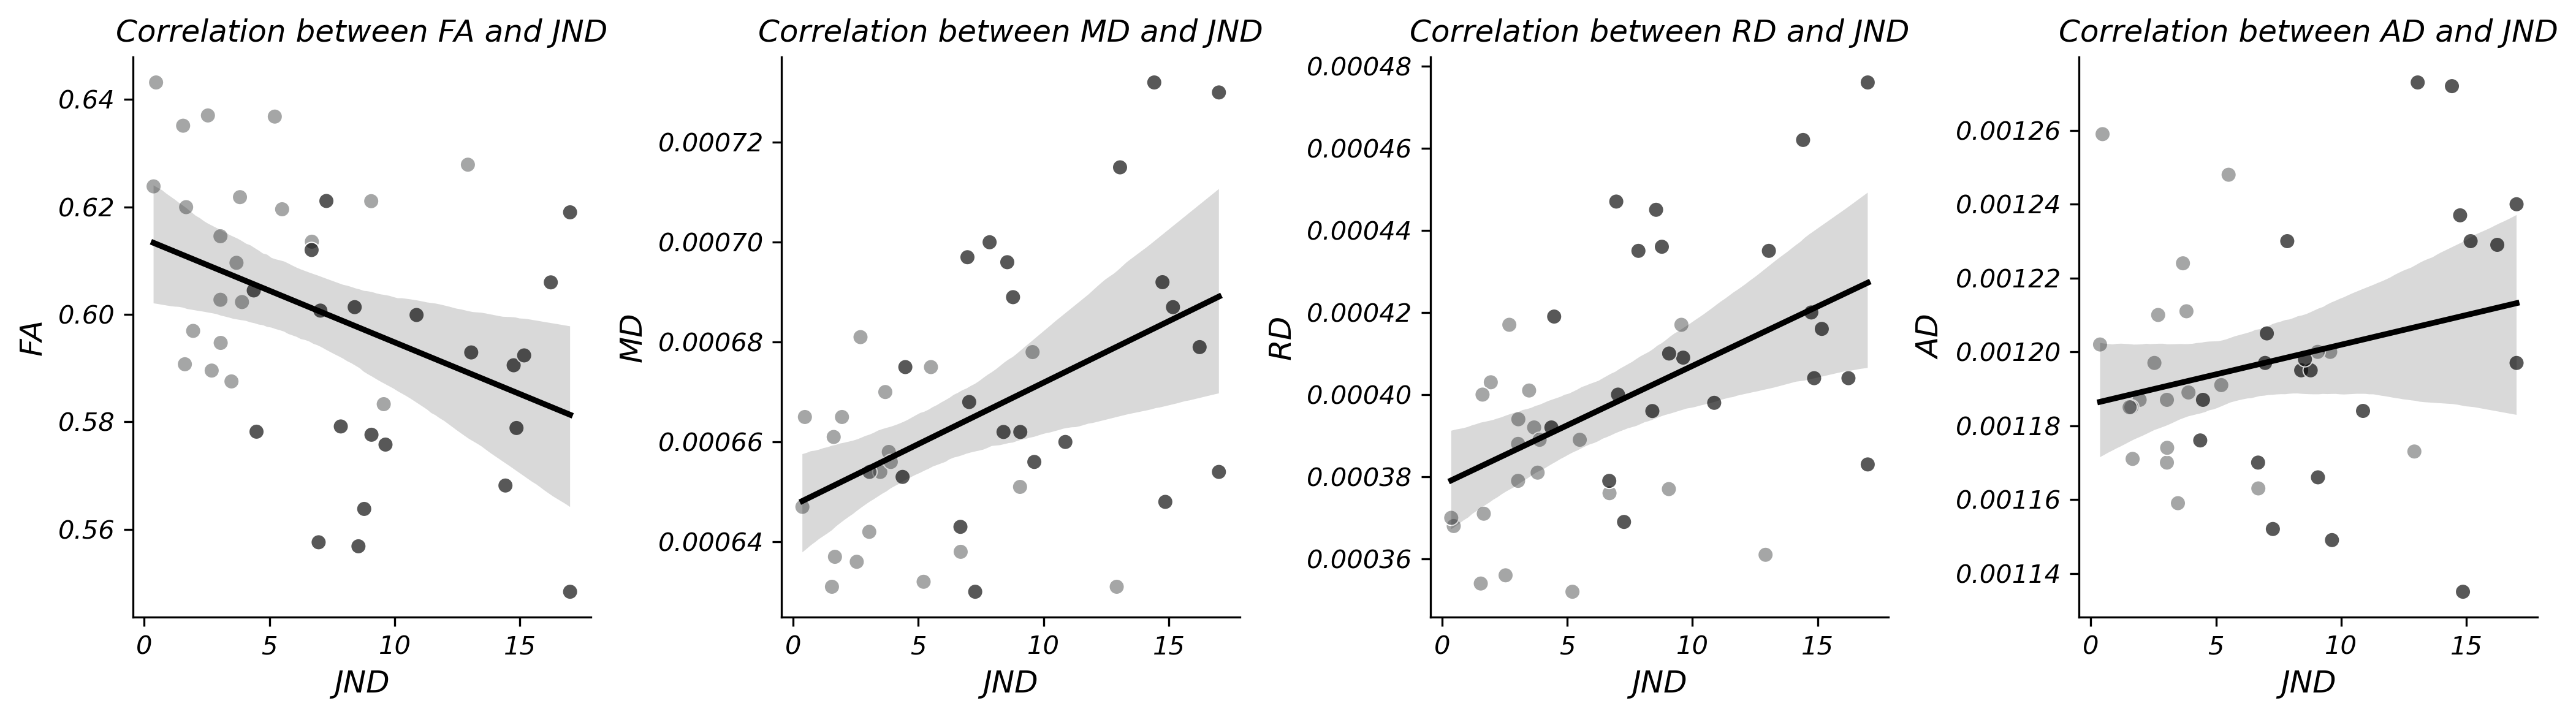

Metric: FA, Correlation: -0.40, p-value: 0.0079
Metric: MD, Correlation: 0.47, p-value: 0.0016
Metric: RD, Correlation: 0.49, p-value: 0.0009
Metric: AD, Correlation: 0.25, p-value: 0.1154


In [7]:
# correlations between DTI metrics in the Body_CC and the JND across all population, hue by color group
x_var = 'JND_P'
fig, axes = plt.subplots(1, 4, figsize=(14,4))
for ax, metric in zip(axes.flatten(), metrics): 
    DTImetric = metric + '_body'
    sns.scatterplot(data=df_CC_body, x=x_var, y=DTImetric, hue='group', ax=ax, palette=group_colors)
    # add a regression line  for all
    sns.regplot(data=df_CC_body, x=x_var, y=DTImetric, ax=ax, scatter=False, color='black')
    ax.set_title(f"Correlation between {metric} and JND", fontsize=12)
    ax.set_xlabel('JND', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.get_legend().remove()
sns.despine()
plt.rcParams['figure.dpi'] = 300
plt.tight_layout()
plt.show()

# correlations between DTI metrics in the Body_CC and the JND across all population
for metric in metrics:
    DTImetric = metric + '_body'
    subset = df_CC_body.dropna(subset=[DTImetric, x_var])
    corr, p_value = pearsonr(subset[DTImetric], subset[x_var])
    print(f"Metric: {metric}, Correlation: {corr:.2f}, p-value: {p_value:.4f}")

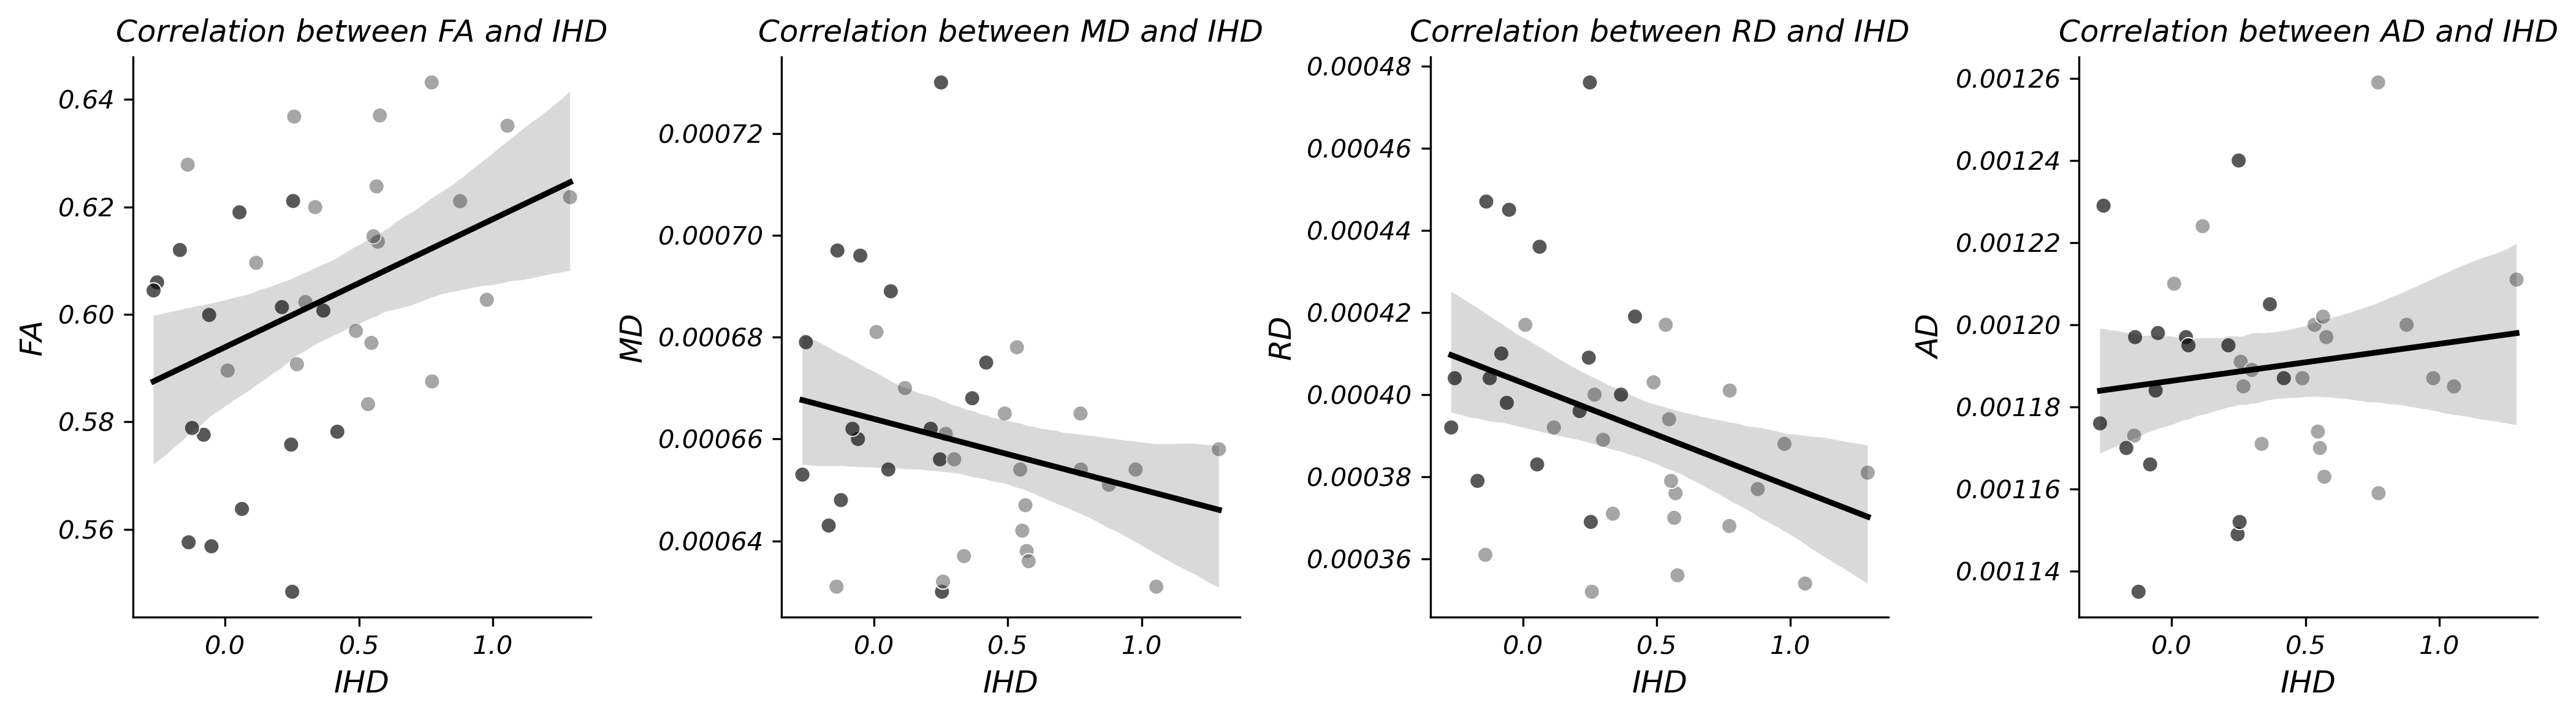

Metric: FA, Correlation: 0.39, p-value: 0.0203
Metric: MD, Correlation: -0.25, p-value: 0.1403
Metric: RD, Correlation: -0.36, p-value: 0.0312
Metric: AD, Correlation: 0.14, p-value: 0.4162


In [8]:
# correlations between DTI metrics in the Body_CC and the IHD across all population, hue by color group
x_var = 'IHD'
fig, axes = plt.subplots(1, 4, figsize=(14,4))
for ax, metric in zip(axes.flatten(), metrics): 
    DTImetric = metric + '_body'
    sns.scatterplot(data=df_CC_body, x=x_var, y=DTImetric, hue='group', ax=ax, palette=group_colors)
    # add a regression line  for all
    sns.regplot(data=df_CC_body, x=x_var, y=DTImetric, ax=ax, scatter=False, color='black')
    ax.set_title(f"Correlation between {metric} and IHD", fontsize=12)
    ax.set_xlabel('IHD', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.get_legend().remove()
sns.despine()
plt.rcParams['figure.dpi'] = 300
plt.tight_layout()
plt.show()

# correlations between DTI metrics in the Body_CC and the IHD across all population
for metric in metrics:
    DTImetric = metric + '_body'
    subset = df_CC_body.dropna(subset=[DTImetric, x_var])
    corr, p_value = pearsonr(subset[DTImetric], subset[x_var])
    print(f"Metric: {metric}, Correlation: {corr:.2f}, p-value: {p_value:.4f}")

## The Genu

/tmp/ipykernel_165115/612915203.py:28: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='group', y=DTImetric, data=df_CC_body, ax=ax, hue='group',
/tmp/ipykernel_165115/612915203.py:28: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='group', y=DTImetric, data=df_CC_body, ax=ax, hue='group',
/tmp/ipykernel_165115/612915203.py:28: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='group', y=DTImetric, data=df_CC_body, ax=ax, hue='group',
/tmp/ipykernel_165115/612915203.py:28: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.str

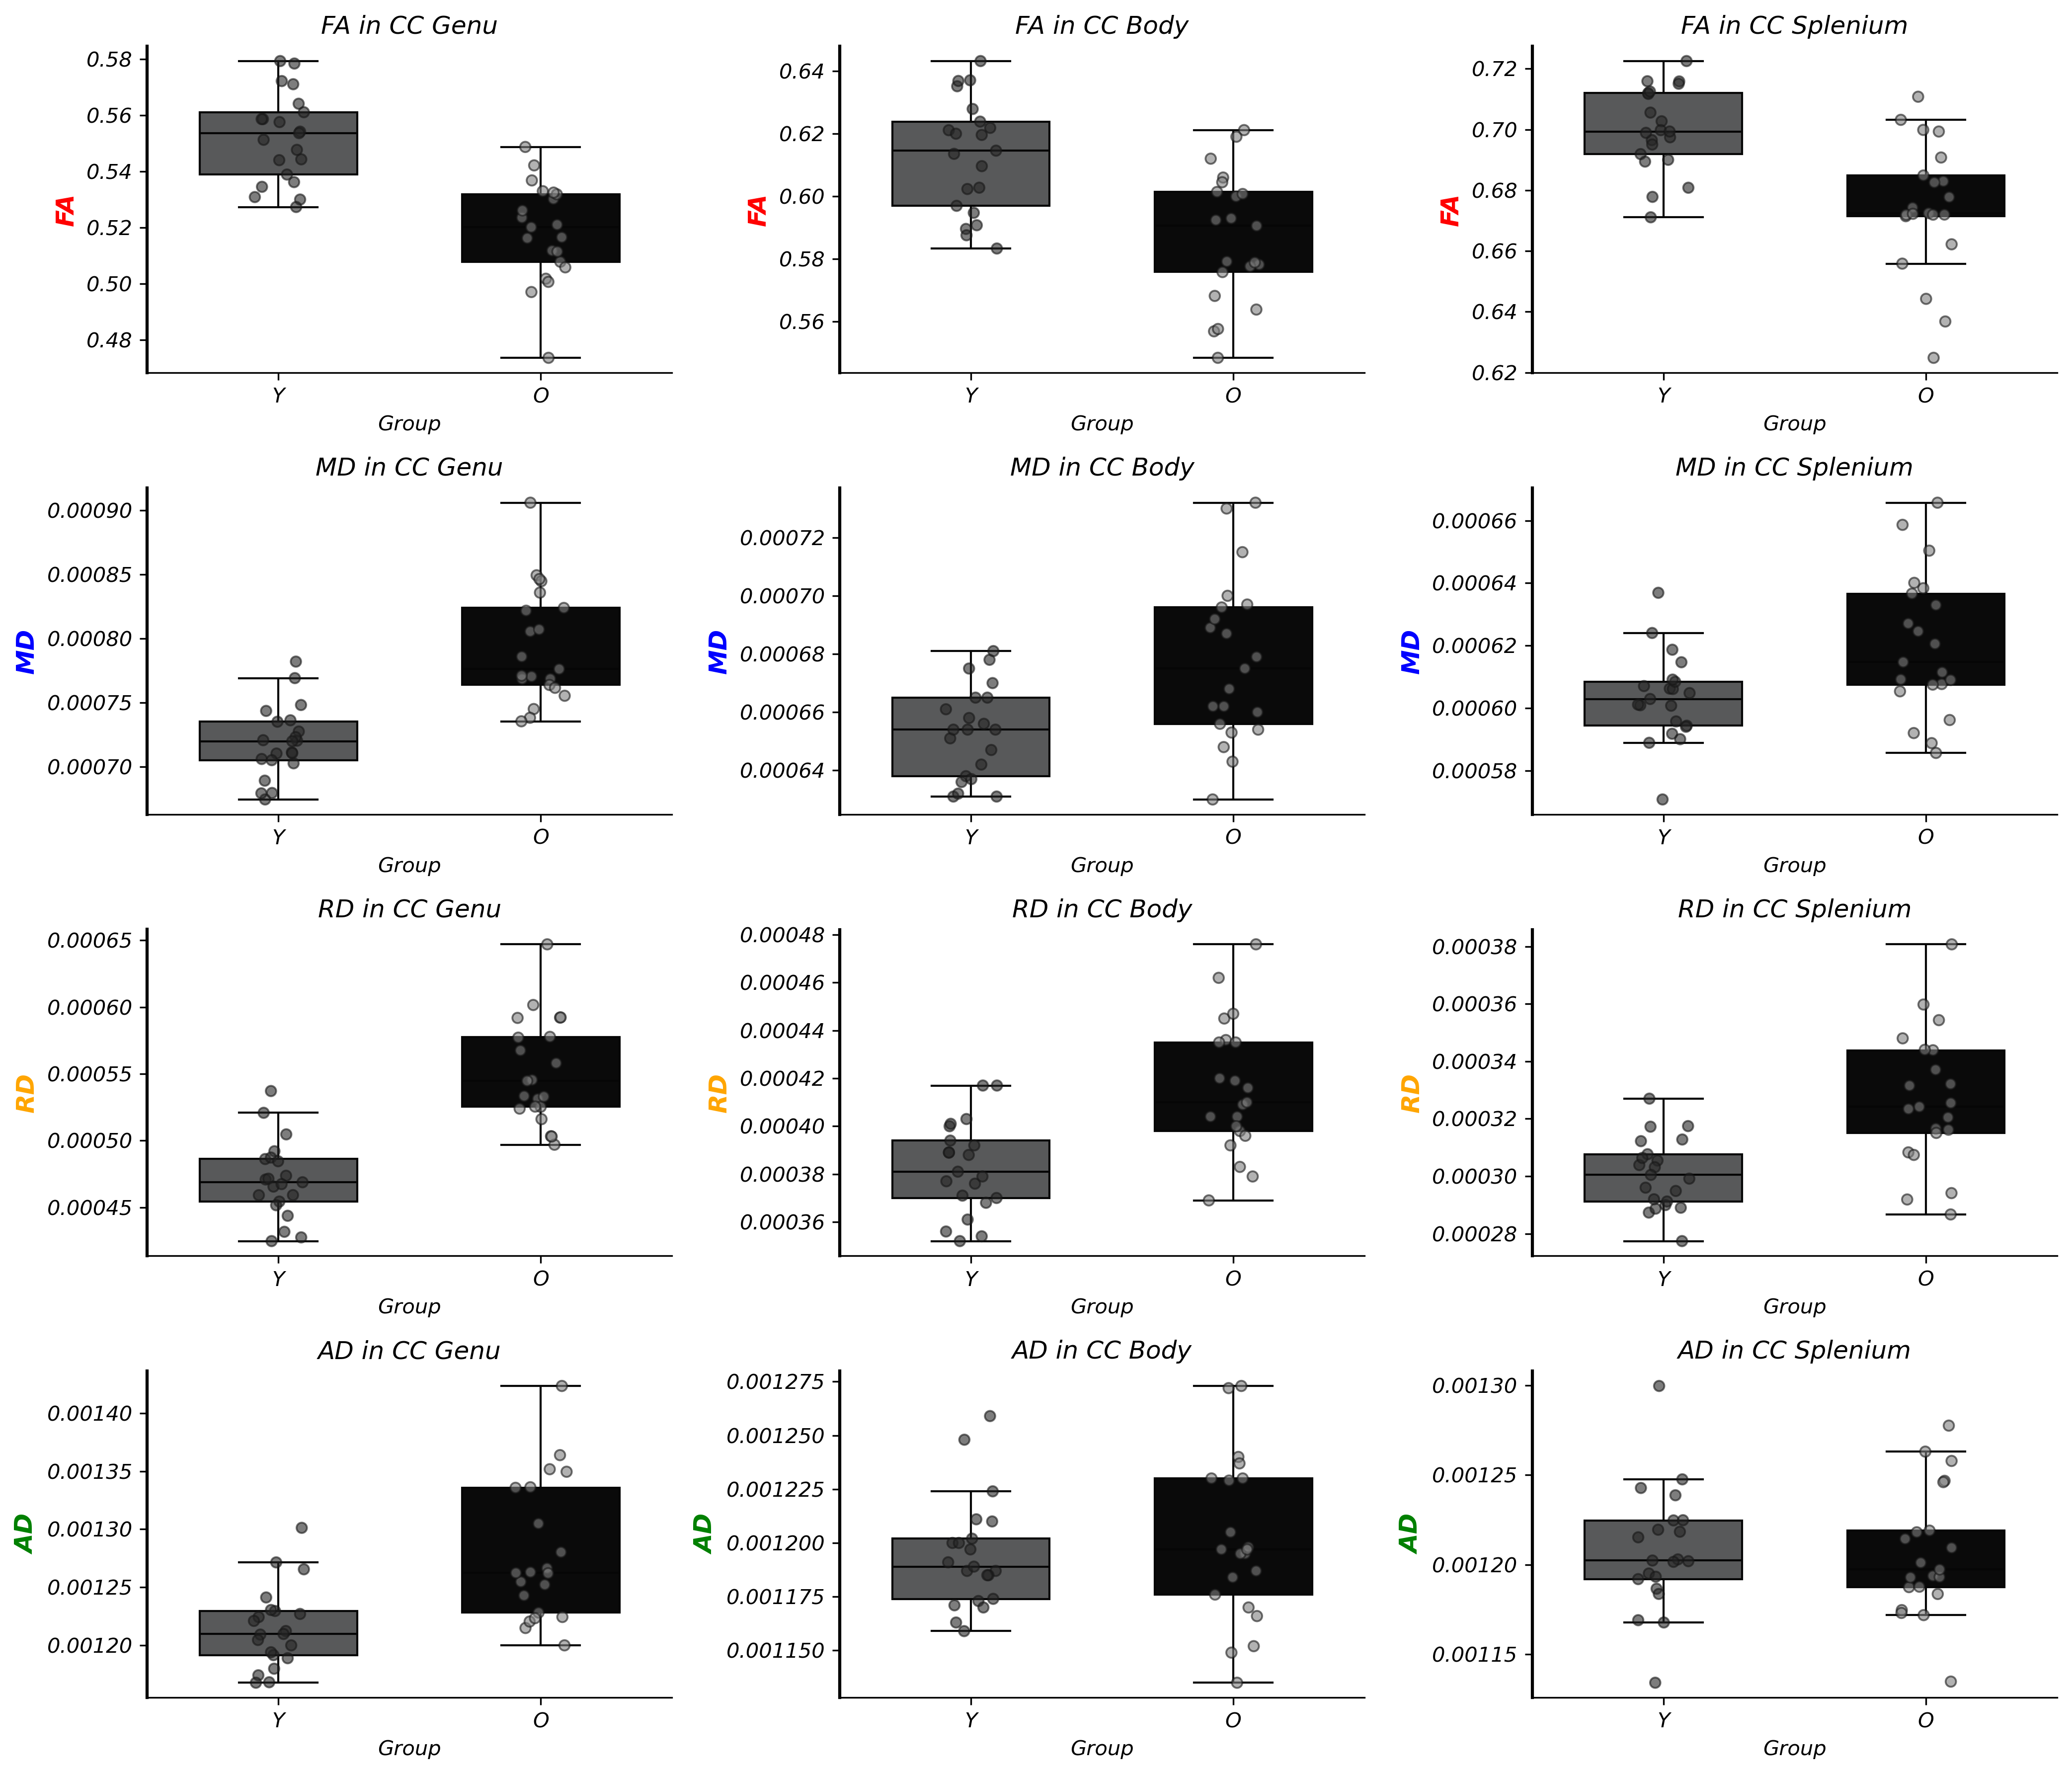

In [36]:
group_colors = {'Y': "#58595A89", 'O': "#0a0a0aae"}
metrics = ['FA', 'MD', 'RD', 'AD']
CCregions = ['genu', 'body', 'splenium']

# 1. Define your metric specific colors
metric_colors = {
    'FA': 'red',
    'MD': 'blue',
    'RD': 'orange',
    'AD': 'green'
}

plt.rcParams['figure.dpi'] = 300
fig, axes = plt.subplots(4, 3, figsize=(14, 12))

for row, metric in enumerate(metrics):
    # Get the color for the current row's metric
    current_color = metric_colors[metric]
    
    for col, i_ccregion in enumerate(CCregions):
        ax = axes[row, col]
        DTImetric = metric + '_' + i_ccregion
        
        sns.boxplot(x='group', y=DTImetric, data=df_CC_body, ax=ax, hue='group', 
                    palette=group_colors, showfliers=False, width=0.6, 
                    boxprops=dict(alpha=1), linewidth=1, legend=False)
        
        sns.stripplot(x='group', y=DTImetric, data=df_CC_body, ax=ax, hue='group', 
                      marker='o', linewidth=0.9, color='gray', alpha=0.6, legend=False)
        
        ax.set_title(f"{metric} in CC {i_ccregion.capitalize()}", fontsize=12)
        ax.set_xlabel('Group', fontsize=10)
        
        # 2. Apply the metric color to the Y-axis elements
        ax.set_ylabel(metric, fontsize=12, color=current_color, weight='bold') # Label color
        ax.spines['left'].set_linewidth(1.5)                                   # Make the spine pop a bit more

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# long dataframe for statistical analysis using LLM

# 1. Ensure your dataframe has a unique identifier column for each person.
if 'sub_id' not in df_CC_body.columns:
    df_CC_body = df_CC_body.reset_index().rename(columns={'index': 'sub_id'})

# 2. Identify the columns you want to melt (the DTI metric columns)
# This dynamically finds all columns containing an underscore (like 'FA_genu')
dti_cols = [col for col in df_CC_body.columns if '_' in col and any(m in col for m in ['FA', 'MD', 'RD', 'AD'])]

# 3. Melt the dataframe from wide to long
df_CC_long = pd.melt(
    df_CC_body,
    id_vars=['sub_id', 'group'],  # Columns to keep as they are
    value_vars=dti_cols,               # Columns to unpivot/melt
    var_name='metric_region',          # Temporary name for the combined column
    value_name='value'                 # The column that will hold the actual numbers
)

# 4. Split the 'metric_region' column into two separate columns: 'metric' and 'region'
df_CC_long[['metric', 'region']] = df_CC_long['metric_region'].str.split('_', expand=True)

# 5. Drop the temporary combined column and reorder for cleanliness
df_CC_long = df_CC_long.drop(columns=['metric_region'])
df_CC_long = df_CC_long[['sub_id', 'group', 'region', 'metric', 'value']]

# save the file
output_filename = "df_CC_long.csv"
save_path = os.path.join(path, output_filename)

# Save to CSV (index=False prevents adding an extra unnamed column)
df_CC_long.to_csv(save_path, index=False)
print(f"Long dataframe successfully saved to: {save_path}")

# View the result
df_CC_long.head()


Long dataframe successfully saved to: /home/daniela/Documents/PROJECTS/Aging_DWI/DTI_MAPS_all/ROIstats/df_CC_long.csv


,sub_id,group,region,metric,value
0,0,Y,body,FA,0.583305
1,1,Y,body,FA,0.613541
2,2,Y,body,FA,0.627874
3,3,Y,body,FA,0.596940
4,4,Y,body,FA,0.637035


In [ ]:

# Loop through each metric automatically
for metric in metrics:
    print("\n" + "="*50)
    print(f"  LINEAR MIXED MODEL RESULTS FOR: {metric}")
    print("="*50)
    
    # Filter for the specific metric
    df_filtered = df_CC_long[df_CC_long['metric'] == metric]
    
    # Fit the model
    model = smf.mixedlm("value ~ group * region", data=df_filtered, groups=df_filtered["sub_id"])
    results = model.fit()
    
    # Print the summary table
    print(results.summary())


  LINEAR MIXED MODEL RESULTS FOR: FA
                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       value   
No. Observations:        126           Method:                   REML    
No. Groups:              42            Scale:                    0.0001  
Min. group size:         3             Log-Likelihood:           340.5409
Max. group size:         3             Converged:                Yes     
Mean group size:         3.0                                             
-------------------------------------------------------------------------
                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                      0.587    0.004 148.711 0.000  0.579  0.595
group[T.Y]                     0.026    0.006   4.668 0.000  0.015  0.037
region[T.genu]                -0.068    0.003 -24.949 0.000 -0.074 -0.063
region[T.splenium]

/home/daniela/anaconda3/envs/demo_desu/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/daniela/anaconda3/envs/demo_desu/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/daniela/anaconda3/envs/demo_desu/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/daniela/anaconda3/envs/demo_desu/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


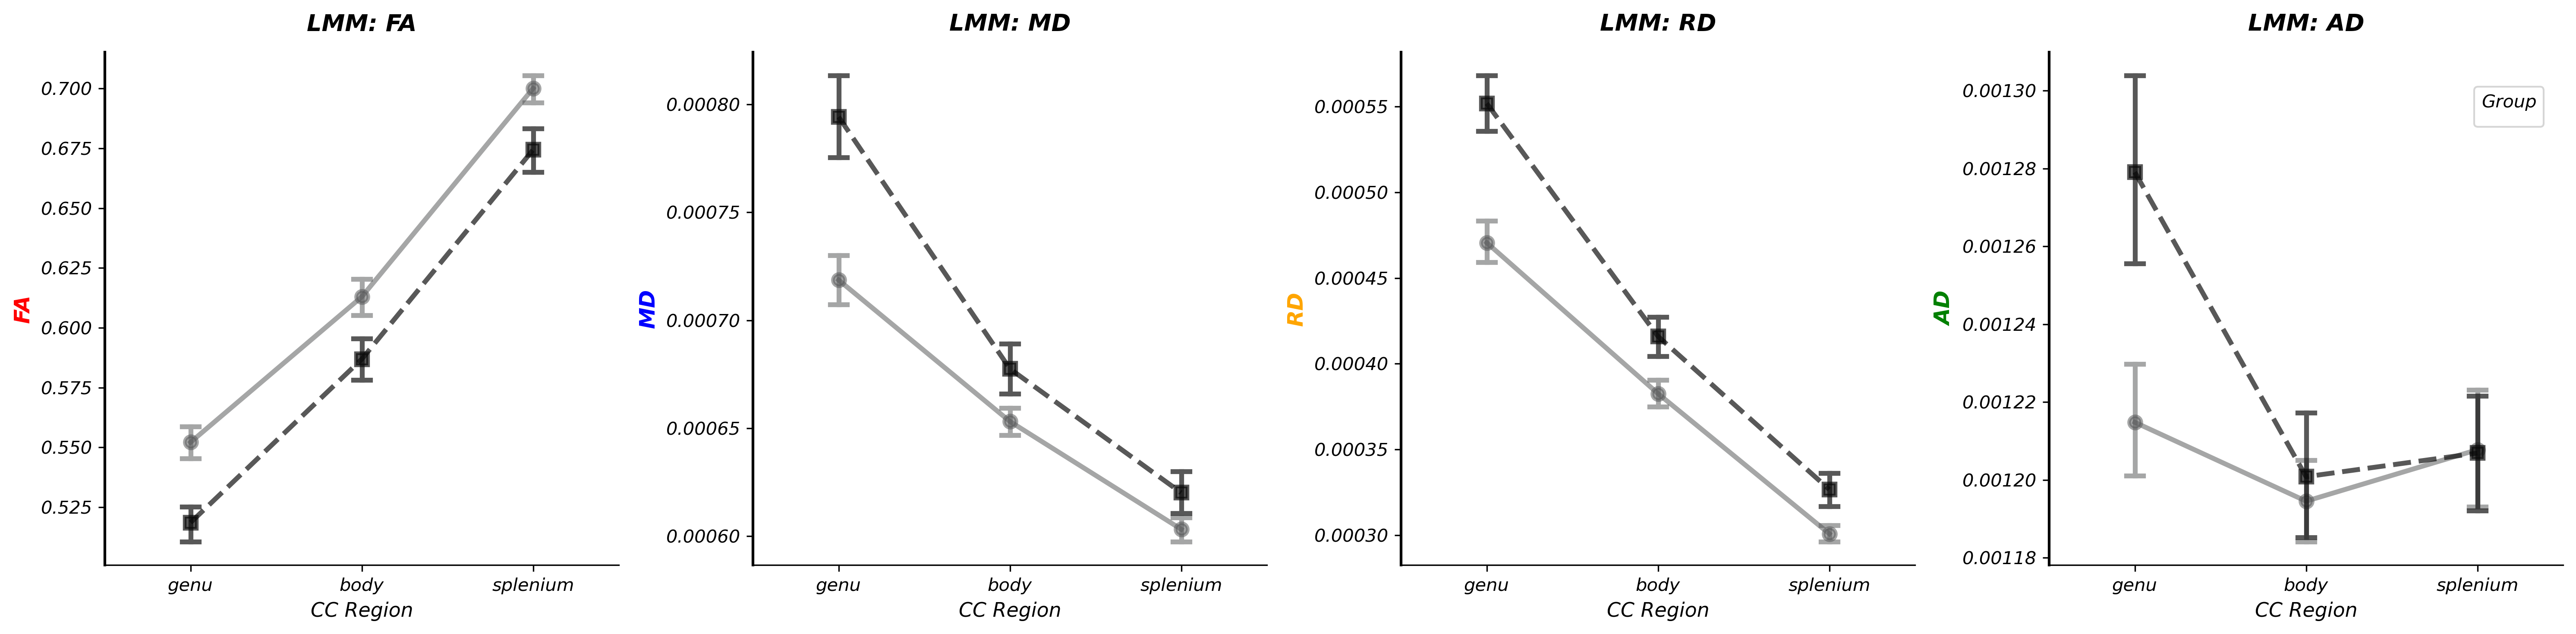

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['FA', 'MD', 'RD', 'AD']
group_colors = {'Y': "#58595A89", 'O': "#0a0a0aae"}
region_order = ['genu', 'body', 'splenium']


# 1. Create a single figure with 1 row and 4 columns
# Adjusted figsize: 20 inches wide gives each subplot plenty of horizontal room
fig, axes = plt.subplots(1, 4, figsize=(20, 5), dpi=300)

# 2. Use zip to loop through the 4 subplots and 4 metrics simultaneously
for ax, metric in zip(axes, metrics):
    # Filter data for the specific metric
    df_filtered = df_CC_long[df_CC_long['metric'] == metric]
    current_color = metric_colors[metric]

    # Pointplot - passed the specific 'ax' to target the correct subplot
    sns.pointplot(
        data=df_filtered, 
        x='region', 
        y='value', 
        hue='group', 
        order=region_order,                       # Force the exact X-axis sequence
        ax=ax,                                     # Crucial: direct plot to its specific subplot
        palette=group_colors, 
        markers=['o', 's'],                      
        linestyles=['-', '--'],                  
        errorbar='ci',                           
        capsize=0.1,
        legend=False                               # Suppress individual legends to keep it clean
    )
    
    # 3. Customize aesthetics for the individual subplot axis (use ax.set_...)
    ax.set_title(f"LMM: {metric}", fontsize=13, pad=12, weight='bold')
    #ax.set_title(metric, fontsize=12, color=current_color, weight='bold') # Label color

    ax.set_xlabel("CC Region", fontsize=11)
    ax.set_ylabel(f"Estimated {metric}", fontsize=11)
    # 2. Apply the metric color to the Y-axis elements
    ax.set_ylabel(metric, fontsize=12, color=current_color, weight='bold') # Label color
    ax.spines['left'].set_linewidth(1.5)                                   # Make the spine pop a bit more


# 4. Create a single, unified legend for the whole figure so it's not repeated 4 times
handles, labels = axes[1].get_legend_handles_labels()
plt.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.95), title='Group')

# Global clean up
sns.despine()
plt.tight_layout()
plt.show()